# DRSI: Decoupled Retrieval-Style Inference — Runnable Demo

This notebook shows how to run the **core idea** of DRSI — Scene-aware Candidate Retrieval (SCR), made of
**Global Route Compliance (GRC)** and **Dynamic Reachability Compliance (DRC)** — directly on the trajectory
vocabulary shipped in this repository (`DRSI/traj_final/16384.npy`).

It reproduces the qualitative retrieval behavior shown in **Fig. 3** of [`Report.pdf`](Report.pdf)
(full vocabulary → after GRC → after DRC) without requiring the full NAVSIM dataset, sensor blobs, or a GPU.

The DRC formula below is ported directly from
[`DRSI/navsim/agents/drsi/drsi_model.py`](DRSI/navsim/agents/drsi/drsi_model.py) (`dynamic_reachability_pruning`).
GRC is approximated geometrically from trajectory endpoints here, since the real GRC cluster file
(`cluster_labels_16384.pkl`) is built from NAVSIM ground-truth logs via
[`DRSI/driving_command_cluster_generator.py`](DRSI/driving_command_cluster_generator.py) — see the
**Full pipeline** section at the end for how to build it and run real training/inference once the dataset is set up.

For links to the presentation video, slides, report, and dataset setup instructions, see
[`README.md`](README.md).

## 1. Load the trajectory vocabulary

In [1]:
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

VOCAB_PATH = Path("DRSI/traj_final/16384.npy")
vocab = np.load(VOCAB_PATH)  # (N, 40, 3) -> (x, y, heading) over a 4s horizon at 10 Hz
print(f"vocab path : {VOCAB_PATH}")
print(f"vocab shape: {vocab.shape}  dtype={vocab.dtype}")
print(f"x range: [{vocab[..., 0].min():.2f}, {vocab[..., 0].max():.2f}] m")
print(f"y range: [{vocab[..., 1].min():.2f}, {vocab[..., 1].max():.2f}] m")

vocab path : DRSI/traj_final/16384.npy
vocab shape: (16384, 40, 3)  dtype=float32
x range: [-1.93, 59.14] m
y range: [-22.33, 21.86] m


## 2. Full vocabulary — Fig. 3(a)

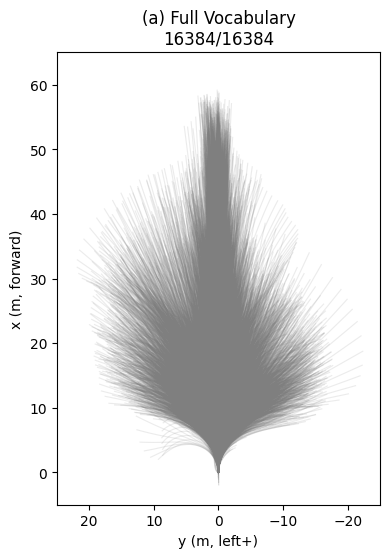

In [2]:
def plot_trajectories(ax, traj, color, title, count, total):
    for t in traj:
        ax.plot(t[:, 1], t[:, 0], color=color, alpha=0.15, linewidth=0.8)
    ax.set_title(f"{title}\n{count}/{total}")
    ax.set_xlabel("y (m, left+)")
    ax.set_ylabel("x (m, forward)")
    ax.set_xlim(-25, 25)
    ax.set_ylim(-5, 65)
    ax.invert_xaxis()  # left is on the left of the plot, matching ego-centric BEV
    ax.set_aspect("equal")

fig, ax = plt.subplots(figsize=(4, 6))
plot_trajectories(ax, vocab, "tab:gray", "(a) Full Vocabulary", vocab.shape[0], vocab.shape[0])
plt.tight_layout()
plt.show()

## 3. Global Route Compliance (GRC) — Fig. 3(b)

GRC maps the one-hot driving command to a precomputed trajectory cluster corresponding to
left / straight / right maneuvers (Eq. 8 in the report), and keeps only candidates whose
global maneuver type matches the route-level command.

The production cluster file is built from GT-log command votes by
`driving_command_cluster_generator.py`. Here we approximate the same left/straight/right
split geometrically from each trajectory's endpoint lateral offset and heading, which is
exactly the rule `step3_fix_mismatch` in that script uses to correct left/right labels.

In [3]:
def assign_command_cluster(vocab, straight_y_thresh=3.0):
    """Geometric stand-in for the GT-log-driven GRC cluster file."""
    endpoint_y = vocab[:, -1, 1]
    left = endpoint_y > straight_y_thresh
    right = endpoint_y < -straight_y_thresh
    straight = ~(left | right)
    return {"left": np.where(left)[0], "straight": np.where(straight)[0], "right": np.where(right)[0]}

clusters = assign_command_cluster(vocab)
for k, v in clusters.items():
    print(f"{k:8s}: {len(v):6d} / {vocab.shape[0]}  ({len(v) / vocab.shape[0] * 100:.1f}%)")

# Scene from Fig. 3: a low-speed RIGHT-turn command
driving_command = "right"
grc_indices = clusters[driving_command]
grc_vocab = vocab[grc_indices]
print(f"\nDriving command: {driving_command!r} -> GRC retains {len(grc_indices)} candidates")

left    :   3182 / 16384  (19.4%)
straight:  10559 / 16384  (64.4%)
right   :   2643 / 16384  (16.1%)

Driving command: 'right' -> GRC retains 2643 candidates


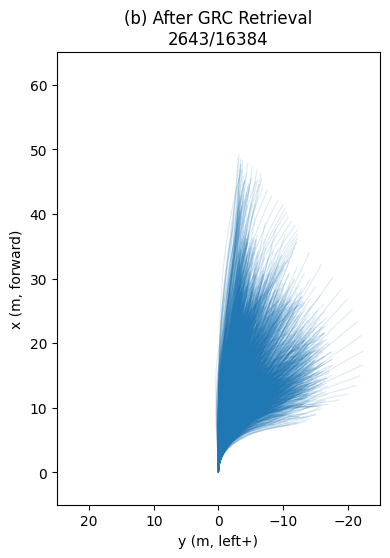

In [4]:
fig, ax = plt.subplots(figsize=(4, 6))
plot_trajectories(ax, grc_vocab, "tab:blue", "(b) After GRC Retrieval", len(grc_indices), vocab.shape[0])
plt.tight_layout()
plt.show()

## 4. Dynamic Reachability Compliance (DRC) — Fig. 3(c)

DRC further removes candidates that are not dynamically reachable from the current ego motion
state, using the soft feasibility kernel of Eq. 9. The cell below is a direct NumPy port of
`DRSITrajHead.dynamic_reachability_pruning` in
[`DRSI/navsim/agents/drsi/drsi_model.py`](DRSI/navsim/agents/drsi/drsi_model.py) (lines ~392–422),
so the retrieval rule matches the trained model exactly — only the tensor backend differs.

In [5]:
def dynamic_reachability_pruning(vocab, current_velocity):
    """NumPy port of DRSITrajHead.dynamic_reachability_pruning (drsi_model.py)."""

    def compute_curvature(p):
        p1, p2, p3 = p[:, 0], p[:, 1], p[:, 2]
        a = np.linalg.norm(p2 - p1, axis=1)
        b = np.linalg.norm(p3 - p2, axis=1)
        c = np.linalg.norm(p3 - p1, axis=1)
        s = (a + b + c) / 2
        area = np.sqrt(np.clip(s * (s - a) * (s - b) * (s - c), 0, None))
        return 4 * area / (a * b * c + 1e-6)

    vx_traj, vy_traj = vocab[:, 10, 0], vocab[:, 10, 1]
    ax_ = (vx_traj - current_velocity[0]) / 0.5

    three_pts = vocab[:, [0, 5, 10], :2]
    kappa = compute_curvature(three_pts)
    ay_ = (vy_traj - current_velocity[1]) / 0.5 + kappa * (vx_traj ** 2 + vy_traj ** 2)

    score_ax_pos = -0.5 * np.tanh(ax_ - 3.0) + 0.5
    score_ax_neg = 0.5 * np.tanh(0.5 * (ax_ + 5.0)) + 0.5
    score_ay = -0.5 * np.tanh(0.5 * np.abs(ay_) - 3.0) + 0.5
    score_drc = ((score_ax_pos * score_ax_neg) + score_ay) / 2.0

    return np.where(score_drc > 0.5)[0]

# Matches the low-speed right-turn scene in Fig. 3 (vx=1.44, vy=0.02, spd=1.44 m/s)
current_velocity = np.array([1.44, 0.02])
drc_local_indices = dynamic_reachability_pruning(grc_vocab, current_velocity)
if drc_local_indices.size == 0:
    drc_local_indices = np.arange(len(grc_indices))  # fallback, mirrors drsi_model.py
drc_indices = grc_indices[drc_local_indices]
drc_vocab = vocab[drc_indices]
print(f"ego velocity (vx, vy) = {tuple(current_velocity)}")
print(f"DRC retains {len(drc_indices)} / {len(grc_indices)} GRC candidates "
      f"({len(drc_indices) / vocab.shape[0] * 100:.1f}% of full vocabulary)")

ego velocity (vx, vy) = (np.float64(1.44), np.float64(0.02))
DRC retains 825 / 2643 GRC candidates (5.0% of full vocabulary)


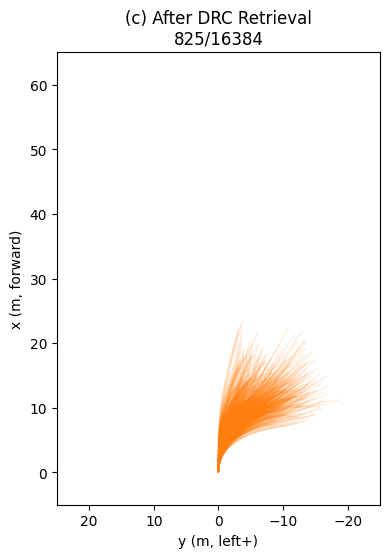

In [6]:
fig, ax = plt.subplots(figsize=(4, 6))
plot_trajectories(ax, drc_vocab, "tab:orange", "(c) After DRC Retrieval", len(drc_indices), vocab.shape[0])
plt.tight_layout()
plt.show()

## 5. Side-by-side comparison (reproduces Fig. 3)

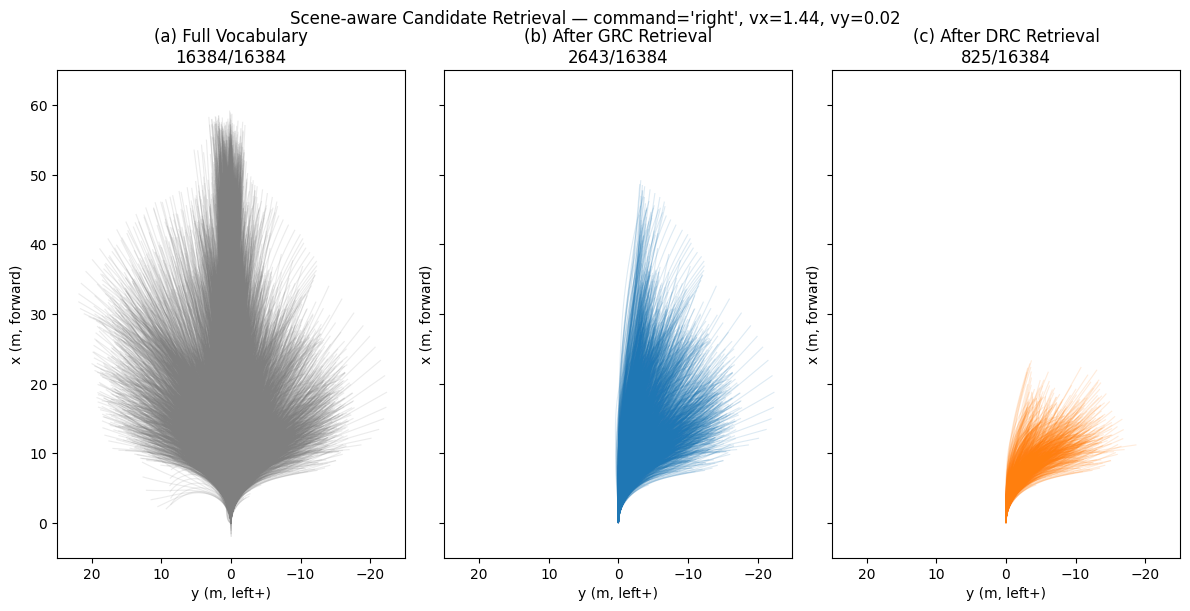

Retrieval funnel:
  Full vocabulary :  16384 (100.0%)
  After GRC       :   2643 ( 16.1%)
  After DRC       :    825 (  5.0%)


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharex=True, sharey=True)
plot_trajectories(axes[0], vocab, "tab:gray", "(a) Full Vocabulary", vocab.shape[0], vocab.shape[0])
plot_trajectories(axes[1], grc_vocab, "tab:blue", "(b) After GRC Retrieval", len(grc_indices), vocab.shape[0])
plot_trajectories(axes[2], drc_vocab, "tab:orange", "(c) After DRC Retrieval", len(drc_indices), vocab.shape[0])
fig.suptitle(f"Scene-aware Candidate Retrieval — command={driving_command!r}, "
             f"vx={current_velocity[0]}, vy={current_velocity[1]}")
plt.tight_layout()
plt.show()

print("Retrieval funnel:")
print(f"  Full vocabulary : {vocab.shape[0]:6d} (100.0%)")
print(f"  After GRC       : {len(grc_indices):6d} ({len(grc_indices) / vocab.shape[0] * 100:5.1f}%)")
print(f"  After DRC       : {len(drc_indices):6d} ({len(drc_indices) / vocab.shape[0] * 100:5.1f}%)")

## 6. Reported results (from `Report.pdf`)

The cells above only demonstrate the retrieval mechanism on the shipped vocabulary file; reproducing the
numbers below requires the full NAVSIM dataset, the pretrained checkpoints, and a GPU (see **Full pipeline**
below and [`README.md`](README.md) → Dataset).

**Table I — Main comparison (NAVSIM v2, single RTX 4090, batch size 1)**

| Method | Vocab. Size | Latency (ms) ↓ | navhard EPDMS ↑ | navtest EPDMS ↑ |
|---|---|---|---|---|
| Baseline (Hydra-MDP++ repro.) | 16,384 | 163.4 | 37.6 | 86.9 |
| Ours (Small) | 8,192 | 21.3 | 38.0 | 85.3 |
| Ours (Large) | 16,384 | **23.9** | **40.2** | 86.1 |

**Table III — Ablation on DRSI components**

| OCI | CA Block | GRC | DRC | EPDMS ↑ | Latency (ms) ↓ |
|---|---|---|---|---|---|
| – | – | – | – | 86.9 | 163.4 |
| ✓ | – | – | – | 86.9 | 93.2 |
| ✓ | ✓ | – | – | 86.2 | 34.1 |
| ✓ | ✓ | ✓ | – | 86.1 | 28.2 |
| ✓ | ✓ | – | ✓ | 86.2 | 27.6 |
| ✓ | ✓ | ✓ | ✓ | 86.1 | **23.9** |

See `Report.pdf` Tables II and IV for the full `navtest` submetric breakdown and the
trajectory-geometry preservation analysis.

## 7. Full pipeline (requires the NAVSIM dataset + GPU)

Not executed in this notebook — these are the commands documented in
[`DRSI/README.md`](DRSI/README.md) and [`DRSI/docs/install.md`](DRSI/docs/install.md) for running the
actual model once the dataset/environment are set up (see [`README.md`](README.md) → Dataset).

```bash
# 1) set up the navsim_workspace environment variables (DRSI/README.md)
source setup_navsim.sh

# 2) build the real GRC cluster file from NAVSIM logs (instead of the geometric stand-in used above)
python DRSI/driving_command_cluster_generator.py \
    --vocab_path DRSI/traj_final/16384.npy \
    --log_dirs $OPENSCENE_DATA_ROOT/navsim_logs/trainval $OPENSCENE_DATA_ROOT/navsim_logs/test \
    --output DRSI/traj_final/cluster_labels_16384.pkl

# 3) train DRSI
./DRSI/scripts/drsi/run_drsi_training.sh

# 4) evaluate EPDMS (navtest / navhard)
./DRSI/scripts/drsi/run_drsi_pdm_score_evaulation.sh
./DRSI/scripts/drsi/run_drsi_pdm_score_evaulation_torchrun_navhard.sh
```